In [53]:
# import package
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib import cm, ticker
import pickle

In [54]:
#%% set parameter and work path
wd_ = 'C:/Users/daizh/manuscript_GougeKinematics_different_evironment_conditions/python_file'
os.chdir(wd_)

In [55]:
# import data

# read in events data

# read P12
filename_ = open('data/events_data/events_P12_.pkl', 'rb')
events_P12_ = pickle.load(filename_)
print('Read events_P12_ done')
filename_.close()

# read P20
filename_ = open('data/events_data/events_P20_.pkl', 'rb')
events_P20_ = pickle.load(filename_)
print('Read events_P20_ done')
filename_.close()

# read P28
filename_ = open('data/events_data/events_P28_.pkl', 'rb')
events_P28_ = pickle.load(filename_)
print('Read events_P28_ done')
filename_.close()

# read P36
filename_ = open('data/events_data/events_P36_.pkl', 'rb')
events_P36_ = pickle.load(filename_)
print('Read events_P36_ done')
filename_.close()

# read P44
filename_ = open('data/events_data/events_P44_.pkl', 'rb')
events_P44_ = pickle.load(filename_)
print('Read events_P44_ done')
filename_.close()

# read Vp25
filename_ = open('data/events_data/events_Vp25_.pkl', 'rb')
events_Vp25_ = pickle.load(filename_)
print('Read events_Vp25_ done')
filename_.close()



# read V01
filename_ = open('data/events_data/events_V01_.pkl', 'rb')
events_V01_ = pickle.load(filename_)
print('Read events_V01_ done')
filename_.close()

# read 2G
filename_ = open('data/events_data/events_2G_.pkl', 'rb')
events_2G_ = pickle.load(filename_)
print('Read events_2G_ done')
filename_.close()


# read 4G
filename_ = open('data/events_data/events_4G_.pkl', 'rb')
events_4G_ = pickle.load(filename_)
print('Read events_4G_ done')
filename_.close()


# read 20G
filename_ = open('data/events_data/events_20G_.pkl', 'rb')
events_20G_ = pickle.load(filename_)
print('Read events_20G_ done')
filename_.close()


# read 80G
filename_ = open('data/events_data/events_80G_.pkl', 'rb')
events_80G_ = pickle.load(filename_)
print('Read events_80G_ done')
filename_.close()



Read events_P12_ done
Read events_P20_ done
Read events_P28_ done
Read events_P36_ done
Read events_P44_ done
Read events_Vp25_ done
Read events_V01_ done
Read events_2G_ done
Read events_4G_ done
Read events_20G_ done
Read events_80G_ done


In [56]:
# define functions
# define a function to statistic vertical to fault
#%% average over a certain distance
def average_along(c_, v_, n_):
    '''
    c_ - the coodinate vector
    v_ - the corresponding coordinate
    n_ - the number of bins

    Returns
    -------
    centers_ - the center of each bins
    values_ - the average value of each bins

    '''
    centers_, values_ = np.zeros(n_), np.zeros(n_)
    count_ = np.zeros(n_)
    max_ = np.max(c_)
    min_ = np.min(c_)
    range_ = (max_ - min_)
    bins_ = np.linspace(min_, max_, n_ + 1)

    # calculate centers
    for i_ in range(n_):
        centers_[i_] = (bins_[i_] + bins_[i_+ 1]) / 2
    
    # calculate values
    for i_ in range(len(c_)):
        index_ = int( (c_[i_] - min_) / (max_ - min_) * n_ )
        if index_ == n_:
            index_ -= 1
        values_[index_] += v_[i_]
        count_[index_] += 1
        # print(index_)
    values_ = values_/count_
    # print(max_)
    # print(min_)
    # print(centers_)
    return centers_, values_
    
#  centers_, values_ = average_along_y(ynew_, vnew_, 10)  



In [57]:
# define the number of event
n_large_ = 49 
n_small_ = 41
n_long_ = 41
n_short_ = 49


Read coordinate done


Read nonaffine done



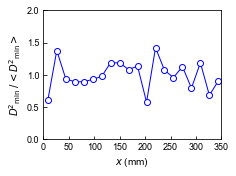

<Figure size 432x288 with 0 Axes>

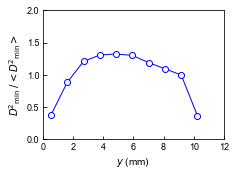

In [58]:
# 1 plot long term
# import data
c_4G_ = np.load('data/coordinate_data/c_former_of_4G_long_term_from_5115_to_19953.npy')
print('\nRead coordinate done\n')
D2min_4G_ = np.load('data/nonaffine_data/nonaffine_of_4G_long_term_from_5115_to_19953.npy')
print('\nRead nonaffine done\n')

# statictics along coordinate x
n_layers_x_ = 20
centers_x_, values_x_ = average_along(c_4G_[:, 0] - c_4G_[:, 0].min(), \
                                      D2min_4G_ / D2min_4G_.mean(), n_layers_x_)   
# statictics along coordinate y
n_layers_y_ = 10
centers_y_, values_y_ = average_along(c_4G_[:, 1] - c_4G_[:, 1].min(), \
                                      D2min_4G_ / D2min_4G_.mean(), n_layers_y_)  
# # plot the results
#  plot x
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_x_, values_x_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([0,2])
plt.xlim([-1, 350])
plt.xticks([0, 50, 100, 150, 200, 250, 300, 350]),
plt.xlabel('$\\mathit{x}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
# # plt.title('Stick')
# #     plt.text( 9, 0.0002, 'Stick')

plt.savefig('notebook_plot/nonaffine_averagex_longterm_4G.svg', format='svg')
plt.show()

#  plot y
plt.clf()
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_y_, values_y_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([0,2])
plt.xlim([0, 12])
plt.xticks([0, 2, 4, 6, 8, 10, 12]),
plt.xlabel('$\\mathit{y}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
plt.savefig('notebook_plot/nonaffine_averagey_longterm_4G.svg', format='svg')
plt.show()

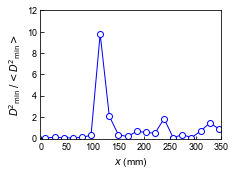

<Figure size 432x288 with 0 Axes>

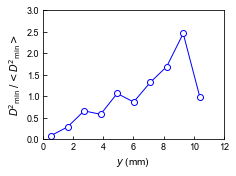

In [59]:
# 2 plot smaller
# import data
condition_ = '4G'

c_smaller_ = np.load('data/coordinate_data/c_former_of_%s_%s_from_%d_to_%d.npy' % \
                 (condition_, 'slip', events_4G_[n_small_][0][0], events_4G_[n_small_][1][0])   )
D2min_smaller_ = np.load('data/nonaffine_data/nonaffine_of_%s_%s_from_%d_to_%d.npy'% \
                        (condition_, 'slip', events_4G_[n_small_][0][0], events_4G_[n_small_][1][0]))

# statictics along coordinate x
n_layers_x_ = 20
centers_x_, values_x_ = average_along(c_smaller_[:, 0] - c_smaller_[:, 0].min(), \
                                      D2min_smaller_ / D2min_smaller_.mean(), n_layers_x_)   
# statictics along coordinate y
n_layers_y_ = 10
centers_y_, values_y_ = average_along(c_smaller_[:, 1] - c_smaller_[:, 1].min(), \
                                      D2min_smaller_ / D2min_smaller_.mean(), n_layers_y_)  
# # plot the results
#  plot x
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_x_, values_x_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([-0.1,12])
plt.xlim([-1, 350])
plt.xticks([0, 50, 100, 150, 200, 250, 300, 350]),
plt.xlabel('$\\mathit{x}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
# # plt.title('Stick')
# #     plt.text( 9, 0.0002, 'Stick')

plt.savefig('notebook_plot/nonaffine_averagex_smallslip_4G.svg', format='svg')
plt.show()

#  plot y
plt.clf()
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_y_, values_y_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([0,3])
plt.xlim([0, 12])
plt.xticks([0, 2, 4, 6, 8, 10, 12]),
plt.xlabel('$\\mathit{y}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
plt.savefig('notebook_plot/nonaffine_averagey_smallslip_4G.svg', format='svg')
plt.show()

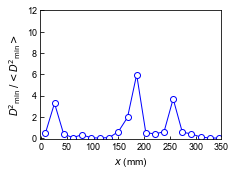

<Figure size 432x288 with 0 Axes>

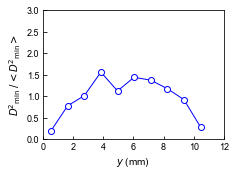

In [60]:
# 3 plot larger
# import data
condition_ = '4G'

c_larger_ = np.load('data/coordinate_data/c_former_of_%s_%s_from_%d_to_%d.npy' % \
                 (condition_, 'slip', events_4G_[n_large_][0][0], events_4G_[n_large_][1][0])   )
D2min_larger_ = np.load('data/nonaffine_data/nonaffine_of_%s_%s_from_%d_to_%d.npy'% \
                        (condition_, 'slip', events_4G_[n_large_][0][0], events_4G_[n_large_][1][0]))

# statictics along coordinate x
n_layers_x_ = 20
centers_x_, values_x_ = average_along(c_larger_[:, 0] - c_larger_[:, 0].min(), \
                                      D2min_larger_ / D2min_larger_.mean(), n_layers_x_)   
# statictics along coordinate y
n_layers_y_ = 10
centers_y_, values_y_ = average_along(c_larger_[:, 1] - c_larger_[:, 1].min(), \
                                      D2min_larger_ / D2min_larger_.mean(), n_layers_y_)  
# # plot the results
#  plot x
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_x_, values_x_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([-0.1,12])
plt.xlim([-1, 350])
plt.xticks([0, 50, 100, 150, 200, 250, 300, 350]),
plt.xlabel('$\\mathit{x}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
# # plt.title('Stick')
# #     plt.text( 9, 0.0002, 'Stick')

plt.savefig('notebook_plot/nonaffine_averagex_largeslip_4G.svg', format='svg')
plt.show()

#  plot y
plt.clf()
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_y_, values_y_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([0,3])
plt.xlim([0, 12])
plt.xticks([0, 2, 4, 6, 8, 10, 12]),
plt.xlabel('$\\mathit{y}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
plt.savefig('notebook_plot/nonaffine_averagey_largeslip_4G.svg', format='svg')
plt.show()

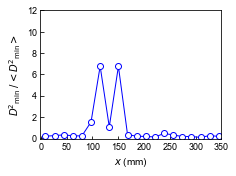

<Figure size 432x288 with 0 Axes>

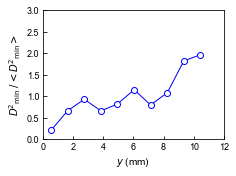

In [61]:
# 4 plot shorter
# import data
condition_ = '4G'

c_short_ = np.load('data/coordinate_data/c_former_of_%s_%s_from_%d_to_%d.npy' % \
                 (condition_, 'stick', events_4G_[n_short_-1][1][0], events_4G_[n_short_][0][0])   )
D2min_short_ = np.load('data/nonaffine_data/nonaffine_of_%s_%s_from_%d_to_%d.npy'% \
                        (condition_, 'stick', events_4G_[n_short_ - 1][1][0], events_4G_[n_short_][0][0]))

# statictics along coordinate x
n_layers_x_ = 20
centers_x_, values_x_ = average_along(c_short_[:, 0] - c_short_[:, 0].min(), \
                                      D2min_short_ / D2min_short_.mean(), n_layers_x_)   
# statictics along coordinate y
n_layers_y_ = 10
centers_y_, values_y_ = average_along(c_short_[:, 1] - c_short_[:, 1].min(), \
                                      D2min_short_ / D2min_short_.mean(), n_layers_y_)  
# # plot the results
#  plot x
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_x_, values_x_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([-0.1,12])
plt.xlim([-1, 350])
plt.xticks([0, 50, 100, 150, 200, 250, 300, 350]),
plt.xlabel('$\\mathit{x}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
# # plt.title('Stick')
# #     plt.text( 9, 0.0002, 'Stick')

plt.savefig('notebook_plot/nonaffine_averagex_shortstick_4G.svg', format='svg')
plt.show()

#  plot y
plt.clf()
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_y_, values_y_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([0,3])
plt.xlim([0, 12])
plt.xticks([0, 2, 4, 6, 8, 10, 12]),
plt.xlabel('$\\mathit{y}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
plt.savefig('notebook_plot/nonaffine_averagey_shortstick_4G.svg', format='svg')
plt.show()

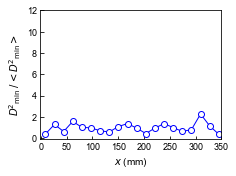

<Figure size 432x288 with 0 Axes>

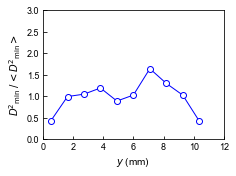

In [62]:
# 5 plot longer
# import data
condition_ = '4G'

c_long_ = np.load('data/coordinate_data/c_former_of_%s_%s_from_%d_to_%d.npy' % \
                 (condition_, 'stick', events_4G_[n_long_-1][1][0], events_4G_[n_long_][0][0])   )
D2min_long_ = np.load('data/nonaffine_data/nonaffine_of_%s_%s_from_%d_to_%d.npy'% \
                        (condition_, 'stick', events_4G_[n_long_ - 1][1][0], events_4G_[n_long_][0][0]))

# statictics along coordinate x
n_layers_x_ = 20
centers_x_, values_x_ = average_along(c_long_[:, 0] - c_long_[:, 0].min(), \
                                      D2min_long_ / D2min_long_.mean(), n_layers_x_)   
# statictics along coordinate y
n_layers_y_ = 10
centers_y_, values_y_ = average_along(c_long_[:, 1] - c_long_[:, 1].min(), \
                                      D2min_long_ / D2min_long_.mean(), n_layers_y_)  
# # plot the results
#  plot x
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_x_, values_x_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([-0.1,12])
plt.xlim([-1, 350])
plt.xticks([0, 50, 100, 150, 200, 250, 300, 350]),
plt.xlabel('$\\mathit{x}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
# # plt.title('Stick')
# #     plt.text( 9, 0.0002, 'Stick')

plt.savefig('notebook_plot/nonaffine_averagex_longstick_4G.svg', format='svg')
plt.show()

#  plot y
plt.clf()
plt.figure(figsize=(3.35,2.52))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9   
plt.plot(centers_y_, values_y_, marker = 'o',markerfacecolor = 'w', linewidth = 1, color = 'b')
plt.ylim([0,3])
plt.xlim([0, 12])
plt.xticks([0, 2, 4, 6, 8, 10, 12]),
plt.xlabel('$\\mathit{y}$ (mm)', fontsize = 10)
plt.ylabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' $\\mathrm{/ <}$' + '$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + '$\\mathrm{>}$', fontsize = 10)
plt.tight_layout()
plt.savefig('notebook_plot/nonaffine_averagey_longstick_4G.svg', format='svg')
plt.show()